In [14]:
# !pip install tensorflow

# Python (version 3.8–3.11 recommended)
#TensorFlow → like driving an automatic car
#PyTorch → like driving a manual car


In [15]:
# better practise  split the dataset into 3 parts
# when we have our own dataset then we use train_test_split from sklearn

# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

Image Processing is the field of analyzing and manipulating images using a computer. It’s the foundation for computer vision, OCR, medical imaging, facial recognition, and more.

What is an Image in Computers?
A digital image is a grid of pixels.
Each pixel has values representing color or intensity.

| Image Type | Pixel Representation                    |
| ---------- | --------------------------------------- |
| Grayscale  | 1 number per pixel (0=black, 255=white) |
| RGB        | 3 numbers per pixel (Red, Green, Blue)  |
| Binary     | 0 or 1 per pixel (black or white)       |


Why Do We Process Images?

Image processing allows computers to:

Enhance images (brightness, contrast)
Detect features (edges, shapes, faces)
Recognize objects (digits, letters, animals)
Prepare images for machine learning (CNNs, OCR)

Basic Steps in Image Processing
Image Acquisition – Get the image from a camera or dataset.
Preprocessing – Resize, crop, normalize, or remove noise.
Analysis/Feature Extraction – Find edges, patterns, or shapes.
Recognition/Classification – Use machine learning to identify objects.
Visualization – Show the processed images for interpretation.

Import libraries
Load dataset
Visualize a few images
Normalize pixel values
Reshape images for CNN
(Optional) Split into train/validation
Build CNN
Train & evaluate

Example: Handwritten Digit Recognition
Dataset → MNIST (images of 0–9 digits)
Preprocessing → Normalize pixel values 0–1
Model → CNN learns patterns from pixels
Prediction → CNN recognizes handwritten digits

MNIST is a collection of:

✍️ Handwritten digits: 0 to 9
🖼️ Grayscale images (black & white)
📏 Image size: 28 × 28 pixels

🔢 Dataset Size
🏋️ Training data: 60,000 images
🧪 Testing data: 10,000 images

📌 train_images
Shape: (60000, 28, 28)
Pixel values (0–255)

📌 train_labels
Shape: (60000,)
Values: 0–9

In [4]:
import tensorflow as tf

# Step 1: Load dataset
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print("Train images shape:", train_images.shape)  # (60000, 28, 28)
print("Train labels shape:", train_labels.shape)  # (60000,)
print("Test images shape:", test_images.shape)    # (10000, 28, 28)
print("Test labels shape:", test_labels.shape)    # (10000,)

# 60,000 training images
# 10,000 test images
# Each image is 28×28 pixels (grayscale)
# Labels are numbers 0–9

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


This is a 4-dimensional NumPy array  <br>
60000 → Number of images in the dataset    <br>
You have 60,000 training images.     <br>
Each one is a separate sample.    <br>
28 → Height of each image (28 pixels)  <br>
28 → Width of each image (28 pixels)     <br>
1 → Number of channels (color depth)     <br>
1 = grayscale (black & white)    <br>
If it were RGB color images, this would be 3 (Red, Green, Blue)

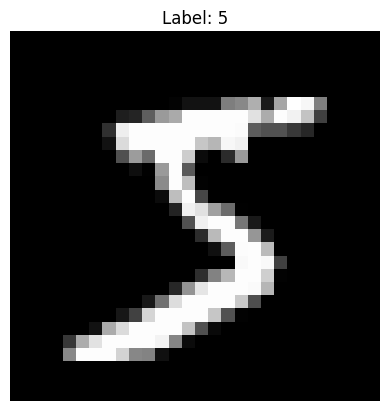

In [16]:
import matplotlib.pyplot as plt
# Plot first image
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")  # show the label
plt.axis('off')
plt.show()

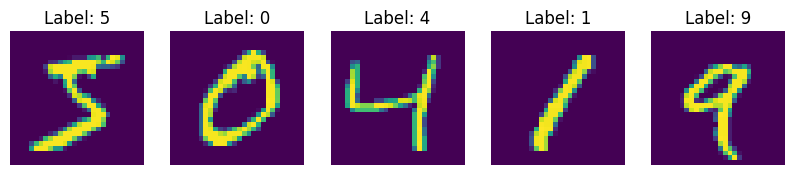

In [17]:
#Show First 5 Images With Labels
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[i])
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.show()

In [18]:
# Step 2: Normalize values (0 to 1)
train_images = train_images / 255.0
test_images = test_images / 255.0

In [19]:
# Step 3: Add channel dimension (important for CNN)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [21]:
# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
model.summary()


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7169 - loss: 0.9511
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8850 - loss: 0.3892
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9021 - loss: 0.3331


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        86,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,152 (1020.13 KB)

 Trainable params: 87,050 (340.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 174,102 (680.09 KB)

In [12]:
# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9772 - loss: 0.0692
Accuracy: 0.9771999716758728


313/313 → all 313 batches done  <br>
1s → total time taken  <br>
3ms/step → average time per batch  <br>
accuracy: 0.9794 → per-batch cumulative accuracy  <br>
loss: 0.0616 → per-batch cumulative loss  <br>

How Batch Number is Calculated <br>

TensorFlow divides test data into batches. By default:  <br>
batch_size = 32  <br>

our test dataset has 10,000 images: <br>

Number of batches = 10000 / 32  ≈ 312.5 ⇒ 313  batches <br> <br>
✅ That’s why you see 313/313. The last batch has fewer images (just 16).

In [13]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9400 - loss: 0.1979
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9800 - loss: 0.0644
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9858 - loss: 0.0475


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,288 (360.50 KB)

 Trainable params: 30,762 (120.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,526 (240.34 KB)

None
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9864 - loss: 0.0432
Accuracy: 0.9864000082015991
